In [99]:
# Cellule 1 — Config & Imports

In [ ]:
# # ══════════════════════════════════════════════════════════════
# #  NOTEBOOK 02 — PREPROCESSING
# #  Un seul paramètre à changer entre les bases
# # ══════════════════════════════════════════════════════════════

# # ── Seul paramètre à modifier ─────────────────────────────────
# BASE_NAME        = "PHARMA"
# MIN_JOURS_SORTIE = 30          # seuil minimum pour Prophet
# GAP_JOURS        = 30          # gap pour détecter date isolée

# # ── Manipulation données ──────────────────────────────────────
# import pandas as pd
# import numpy as np

# # ── Visualisation ─────────────────────────────────────────────
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ── Connexion SQL Server ──────────────────────────────────────
# import pyodbc

# # ── ML ────────────────────────────────────────────────────────
# from sklearn.preprocessing import StandardScaler

# # ── Utilitaires ───────────────────────────────────────────────
# import warnings
# import os
# warnings.filterwarnings('ignore')

# # ── Style graphes ─────────────────────────────────────────────
# sns.set_theme(style="whitegrid", palette="muted")
# plt.rcParams['figure.figsize'] = (14, 5)
# plt.rcParams['figure.dpi']     = 120

# # ── Dossiers de sortie ────────────────────────────────────────
# OUTPUT_DIR    = f"../../output/{BASE_NAME}/data_clean/"
# EXPLORE_DIR   = f"../../output/{BASE_NAME}/exploration/"
# os.makedirs(OUTPUT_DIR,  exist_ok=True)
# os.makedirs(EXPLORE_DIR, exist_ok=True)

# print("✅ Imports OK")
# print(f"📦 Base ciblée  : {BASE_NAME}")
# print(f"📁 Output clean : {OUTPUT_DIR}")

✅ Imports OK
📦 Base ciblée  : PHARMA
📁 Output clean : ../../output/PHARMA/data_clean/


In [ ]:
# ══════════════════════════════════════════════════════════════
#  NOTEBOOK 02 — PREPROCESSING
# ══════════════════════════════════════════════════════════════

# ── Imports d'abord ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc
import warnings
import os
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi']     = 120

# ── Config depuis fichier central ─────────────────────────────
import sys
import importlib
sys.path.append(os.path.join(".."))
import config
importlib.reload(config)
from config import *

# ── Dossiers de sortie ────────────────────────────────────────
OUTPUT_DIR  = f"../../output/{BASE_NAME}/data_clean/"
EXPLORE_DIR = f"../../output/{BASE_NAME}/exploration/"
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(EXPLORE_DIR, exist_ok=True)

print("✅ Imports OK")
print(f"✅ Config chargée — Base : {BASE_NAME}")
print(f"📁 Output clean : {OUTPUT_DIR}")

In [101]:
# Cellule 2 — Connexion + Chargement

In [ ]:
# # ── Connexion SQL Server ──────────────────────────────────────
# conn = pyodbc.connect(
#     "DRIVER={ODBC Driver 17 for SQL Server};"
#     "SERVER=SALMAIKSOD\SAGE100;"
#     "DATABASE=Test;"
#     "UID=sa;PWD=123456;"
# )

# print(f"✅ Connecté à SQL Server")
# print(f"📦 Base ciblée : {BASE_NAME}")

✅ Connecté à SQL Server
📦 Base ciblée : PHARMA


In [ ]:
# ── Connexion SQL Server ──────────────────────────────────────
conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SQL_SERVER};"
    f"DATABASE={SQL_DATABASE};"
    f"UID={SQL_UID};PWD={SQL_PWD};"
)

print(f"✅ Connecté à SQL Server")
print(f"📦 Base ciblée : {BASE_NAME}")

In [103]:
# ── Chargement mouvements ─────────────────────────────────────
query_mvt = f"""
SELECT
    DateJour, AR_Ref, AR_Design,
    FA_CodeFamille, FA_Intitule,
    CL_No1, CL_Intitule1,
    CL_No2, CL_Intitule2,
    CL_No3, CL_Intitule3,
    CL_No4, CL_Intitule4,
    DE_No, DE_Intitule,
    TotalEntree, TotalSortie,
    ValeurEntree, ValeurSortie,
    TotalValeurMouvement
FROM Test.stock.VW_MouvementsJournaliers
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_mvt = pd.read_sql(query_mvt, conn)
df_mvt['DateJour'] = pd.to_datetime(df_mvt['DateJour'])

print(f" Mouvements chargés    : {len(df_mvt):,} lignes")
print(f"📅 Période brute         : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}")
print(f"   Articles              : {df_mvt['AR_Ref'].nunique()}")
print(f"   Dépôts                : {df_mvt['DE_No'].nunique()}")

 Mouvements chargés    : 101,512 lignes
📅 Période brute         : 2024-01-01 → 2026-06-10
   Articles              : 154
   Dépôts                : 3


In [104]:
# ── Chargement stock journalier ───────────────────────────────
query_stock = f"""
SELECT
    DateJour, AR_Ref, AR_Design,
    FA_CodeFamille, FA_Intitule,
    CL_No1, CL_Intitule1,
    DE_No, DE_Intitule,
    TotalEntree, TotalSortie,
    ValeurEntree, ValeurSortie,
    StockInitial, StockFinal,
    ValeurInitiale, ValeurFinale
FROM Test.stock.StockJournalierCache
WHERE BaseName = '{BASE_NAME}'
ORDER BY DateJour, AR_Ref, DE_No
"""

df_stock = pd.read_sql(query_stock, conn)
df_stock['DateJour'] = pd.to_datetime(df_stock['DateJour'])

print(f" Stock journalier chargé : {len(df_stock):,} lignes")

 Stock journalier chargé : 101,512 lignes


In [105]:
# Cellule 3 — Nettoyer les dates aberrantes

In [106]:
# ── Sauvegarder la période originale pour le résumé final ─────
date_debut_originale = df_mvt['DateJour'].min().date()
date_fin_originale   = df_mvt['DateJour'].max().date()
nb_articles_initial  = df_mvt['AR_Ref'].nunique()

# ── Détecter les dates isolées (début, milieu, fin) ───────────
dates  = pd.Series(df_mvt['DateJour'].sort_values().unique())

gaps_avant = dates.diff()
gaps_apres = dates.diff(-1).abs()

# Date isolée au milieu : grand trou avant ET après
isolees_milieu = dates[
    (gaps_avant > pd.Timedelta(days=GAP_JOURS)) &
    (gaps_apres > pd.Timedelta(days=GAP_JOURS))
]

# Première date isolée : seulement grand trou après
isolee_debut = pd.Series(dtype='datetime64[ns]')
if gaps_apres.iloc[0] > pd.Timedelta(days=GAP_JOURS):
    isolee_debut = dates.iloc[[0]]

# Dernière date isolée : seulement grand trou avant
isolee_fin = pd.Series(dtype='datetime64[ns]')
if gaps_avant.iloc[-1] > pd.Timedelta(days=GAP_JOURS):
    isolee_fin = dates.iloc[[-1]]

# Toutes les dates aberrantes détectées
dates_aberrantes = pd.concat([
    isolee_debut,
    isolees_milieu,
    isolee_fin
]).unique()

# ── Vérifier et supprimer seulement si peu de données ─────────
SEUIL_LIGNES = 5  # supprimer si moins de 5 lignes

if len(dates_aberrantes) > 0:
    print("Dates détectées — vérification :")
    dates_a_supprimer = []
    for d in sorted(dates_aberrantes):
        nb = len(df_mvt[df_mvt['DateJour'] == d])
        if nb < SEUIL_LIGNES:
            dates_a_supprimer.append(d)
            print(f"   → {pd.Timestamp(d).date()} : {nb} lignes → SUPPRIMÉE")
        else:
            print(f"   → {pd.Timestamp(d).date()} : {nb} lignes → CONSERVÉE")

    if dates_a_supprimer:
        df_mvt   = df_mvt[~df_mvt['DateJour'].isin(dates_a_supprimer)]
        df_stock = df_stock[~df_stock['DateJour'].isin(dates_a_supprimer)]
        print(f"\n⚠️  Dates supprimées : {len(dates_a_supprimer)}")
    else:
        print("\n✅ Toutes les dates conservées")
else:
    print("✅ Aucune date aberrante détectée")

print(f"📅 Période après nettoyage : {df_mvt['DateJour'].min().date()} → {df_mvt['DateJour'].max().date()}")

✅ Aucune date aberrante détectée
📅 Période après nettoyage : 2024-01-01 → 2026-06-10


In [107]:
# Cellule 4 — Traiter les valeurs manquantes

In [108]:
# ── Détecter dynamiquement toutes les colonnes avec NaN ───────
cols_nan_mvt   = df_mvt.columns[df_mvt.isnull().any()].tolist()
cols_nan_stock = df_stock.columns[df_stock.isnull().any()].tolist()

print(f"Colonnes avec NaN dans df_mvt   : {len(cols_nan_mvt)}")
for col in cols_nan_mvt:
    nb  = df_mvt[col].isnull().sum()
    pct = nb / len(df_mvt) * 100
    print(f"   {col:25s} → {nb:,} NaN ({pct:.1f}%)")

print(f"\nColonnes avec NaN dans df_stock : {len(cols_nan_stock)}")
for col in cols_nan_stock:
    nb  = df_stock[col].isnull().sum()
    pct = nb / len(df_stock) * 100
    print(f"   {col:25s} → {nb:,} NaN ({pct:.1f}%)")

# ── Traitement df_mvt ─────────────────────────────────────────
for col in cols_nan_mvt:
    if df_mvt[col].dtype == object:
        df_mvt[col] = df_mvt[col].fillna("INCONNU")
    else:
        df_mvt[col] = df_mvt[col].fillna(0)

# ── Traitement df_stock ───────────────────────────────────────
for col in cols_nan_stock:
    if df_stock[col].dtype == object:
        df_stock[col] = df_stock[col].fillna("INCONNU")
    else:
        df_stock[col] = df_stock[col].fillna(0)

# ── Vérification ──────────────────────────────────────────────
nan_mvt   = df_mvt.isnull().sum().sum()
nan_stock = df_stock.isnull().sum().sum()
print(f"\n✅ NaN restants df_mvt   : {nan_mvt}")
print(f"✅ NaN restants df_stock : {nan_stock}")

Colonnes avec NaN dans df_mvt   : 0

Colonnes avec NaN dans df_stock : 0

✅ NaN restants df_mvt   : 0
✅ NaN restants df_stock : 0


In [109]:
# ══════════════════════════════════════════════════════════════
#  CELLULE 4b — Nettoyage universel (fonctionne sur toute base)
#  Gère : prix négatifs, prix nuls, qté négatives, qté nulles,
#         DE_No NULL, DL_MvtStock invalide, doublons, stock négatif
# ══════════════════════════════════════════════════════════════

nb_avant = len(df_mvt)

# ── 1. Supprimer doublons exacts ──────────────────────────────
df_mvt   = df_mvt.drop_duplicates()
df_stock = df_stock.drop_duplicates()

# ── 2. Filtrer quantités invalides ───────────────────────────
df_mvt   = df_mvt[df_mvt['TotalSortie']  >= 0]
df_mvt   = df_mvt[df_mvt['TotalEntree']  >= 0]
df_stock = df_stock[df_stock['TotalSortie'] >= 0]
df_stock = df_stock[df_stock['TotalEntree'] >= 0]

# ── 3. Filtrer prix négatifs ou nuls ─────────────────────────
# ValeurEntree et ValeurSortie : remplacer les négatifs par 0
for col in ['ValeurEntree', 'ValeurSortie', 'TotalValeurMouvement']:
    if col in df_mvt.columns:
        df_mvt[col] = df_mvt[col].clip(lower=0)

for col in ['ValeurEntree', 'ValeurSortie']:
    if col in df_stock.columns:
        df_stock[col] = df_stock[col].clip(lower=0)

# ── 4. Filtrer prix aberrants (z-score > 4 par article) ──────
# S'applique sur ValeurSortie / TotalSortie pour détecter ×10 ou ÷100
def filter_zscore(df, col, threshold=4.0):
    """Remplace les valeurs aberrantes par la médiane de l'article."""
    if col not in df.columns:
        return df
    grp = df.groupby('AR_Ref')[col]
    median = grp.transform('median')
    std    = grp.transform('std').fillna(1)
    z      = ((df[col] - median) / std).abs()
    df.loc[z > threshold, col] = median[z > threshold]
    return df

df_mvt   = filter_zscore(df_mvt,   'TotalSortie')
df_mvt   = filter_zscore(df_mvt,   'ValeurSortie')
df_stock = filter_zscore(df_stock, 'TotalSortie')
df_stock = filter_zscore(df_stock, 'StockFinal')

# ── 5. Supprimer AR_Ref orphelins (pas dans la dimension) ────
ar_refs_valides = df_mvt['AR_Ref'].unique()
df_stock = df_stock[df_stock['AR_Ref'].isin(ar_refs_valides)]

# ── 6. Imputer DE_No NULL → mode par AR_Ref ──────────────────
if df_mvt.get('DE_No') is not None and df_mvt['DE_No'].isnull().any():
    mode_depot = df_mvt.groupby('AR_Ref')['DE_No'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else 1
    )
    df_mvt['DE_No'] = df_mvt['DE_No'].fillna(mode_depot)

# ── 7. Nettoyage colonnes texte (encodage bizarre) ────────────
for col in ['AR_Design', 'FA_CodeFamille', 'FA_Intitule',
            'DE_Intitule', 'CL_Intitule1', 'CL_Intitule2']:
    if col in df_mvt.columns:
        # Supprimer entités HTML (&amp; &#233; etc.)
        df_mvt[col] = df_mvt[col].str.replace(r'&#?\w+;', '', regex=True)
        # Supprimer caractères non imprimables / points d'interrogation
        df_mvt[col] = df_mvt[col].str.replace(r'[^\x20-\x7EÀ-ÿ]', '', regex=True)
        # Strip espaces superflus
        df_mvt[col] = df_mvt[col].str.strip()
        # Remplacer vides par INCONNU
        df_mvt[col] = df_mvt[col].replace('', 'INCONNU').fillna('INCONNU')

nb_apres = len(df_mvt)
print(f"- Nettoyage universel terminé")
print(f"   Lignes avant  : {nb_avant:,}")
print(f"   Lignes après  : {nb_apres:,}")
print(f"   Supprimées    : {nb_avant - nb_apres:,}")
print(f"   NaN df_mvt    : {df_mvt.isnull().sum().sum()}")
print(f"   NaN df_stock  : {df_stock.isnull().sum().sum()}")

- Nettoyage universel terminé
   Lignes avant  : 101,512
   Lignes après  : 101,512
   Supprimées    : 0
   NaN df_mvt    : 0
   NaN df_stock  : 0


In [110]:
# Cellule 5 — Calendrier complet

In [111]:
# ── Calendrier complet de la période ─────────────────────────
date_debut = df_mvt['DateJour'].min()
date_fin   = df_mvt['DateJour'].max()

print(f"📅 Période     : {date_debut.date()} → {date_fin.date()}")

# ── Construire calendrier uniquement sur combinaisons réelles ─
# (pas toutes les combinaisons article × dépôt)
combinaisons_reelles = df_stock[['AR_Ref', 'DE_No']].drop_duplicates()

print(f"   Combinaisons article×dépôt réelles : {len(combinaisons_reelles)}")

dfs = []
for _, row in combinaisons_reelles.iterrows():
    cal = pd.DataFrame({'DateJour': pd.date_range(date_debut, date_fin)})
    cal['AR_Ref'] = row['AR_Ref']
    cal['DE_No']  = row['DE_No']
    dfs.append(cal)

df_calendar = pd.concat(dfs, ignore_index=True)

# ── Merger avec le stock réel ─────────────────────────────────
df_full = df_calendar.merge(
    df_stock,
    on=['DateJour', 'AR_Ref', 'DE_No'],
    how='left'
)

nb_jours_total    = df_full['DateJour'].nunique()
nb_jours_avec_mvt = df_stock['DateJour'].nunique()
nb_jours_remplis  = nb_jours_total - nb_jours_avec_mvt

print(f"\n- Calendrier construit")
print(f"   Jours total          : {nb_jours_total}")
print(f"   Jours avec mouvement : {nb_jours_avec_mvt}")
print(f"   Jours à remplir      : {nb_jours_remplis}")
print(f"   Lignes df_full       : {len(df_full):,}")

📅 Période     : 2024-01-01 → 2026-06-10
   Combinaisons article×dépôt réelles : 154

- Calendrier construit
   Jours total          : 892
   Jours avec mouvement : 892
   Jours à remplir      : 0
   Lignes df_full       : 137,368


In [112]:
# Cellule 6 — Remplir les jours sans mouvement

In [113]:
# ══════════════════════════════════════════════════════════════
#  CELLULE 6 — Remplir les jours sans mouvement (version robuste)
#  Ajout : filtre stock négatif universel
# ══════════════════════════════════════════════════════════════

df_full = df_full.sort_values(['AR_Ref', 'DE_No', 'DateJour'])

# ── TotalSortie et TotalEntree → 0 si pas de mouvement ────────
df_full['TotalSortie']  = df_full['TotalSortie'].fillna(0)
df_full['TotalEntree']  = df_full['TotalEntree'].fillna(0)
df_full['ValeurSortie'] = df_full['ValeurSortie'].fillna(0)
df_full['ValeurEntree'] = df_full['ValeurEntree'].fillna(0)

# ── StockFinal → reporter la dernière valeur connue ───────────
df_full['StockFinal'] = df_full.groupby(['AR_Ref', 'DE_No'])['StockFinal'] \
                                .transform(lambda x: x.ffill())

# ── ✅ NOUVEAU : Remplacer stock négatif par 0 (universel) ────
# Gère les bases avec sorties > entrées (erreurs ou données sales)
nb_negatifs = (df_full['StockFinal'] < 0).sum()
if nb_negatifs > 0:
    print(f"⚠️  {nb_negatifs:,} lignes avec StockFinal < 0 → remplacées par 0")
    df_full['StockFinal'] = df_full['StockFinal'].clip(lower=0)
else:
    print("✅ Aucun stock négatif détecté")

# ── Colonnes texte → propager la valeur connue ────────────────
cols_texte = ['AR_Design', 'FA_CodeFamille', 'FA_Intitule',
              'DE_Intitule', 'CL_No1', 'CL_Intitule1',
              'CL_No2', 'CL_Intitule2']

for col in cols_texte:
    if col in df_full.columns:
        df_full[col] = df_full.groupby(['AR_Ref', 'DE_No'])[col] \
                               .transform(lambda x: x.ffill().bfill())

# ── Vérification ──────────────────────────────────────────────
nan_stock = df_full['StockFinal'].isnull().sum()
print(f"- Jours remplis")
print(f"   NaN restants StockFinal : {nan_stock}")
print(f"   (NaN = articles sans aucun stock historique)")

✅ Aucun stock négatif détecté
- Jours remplis
   NaN restants StockFinal : 0
   (NaN = articles sans aucun stock historique)


In [114]:
# Cellule 7 — Agréger par article (supprimer dépôts)

In [115]:
# ── Agréger tous les dépôts par article ──────────────────────
# Prophet, RF, K-Means travaillent sur l'article total
# pas article × dépôt

df_total = df_full.groupby(['DateJour', 'AR_Ref']).agg(
    AR_Design      = ('AR_Design',      'first'),
    FA_CodeFamille = ('FA_CodeFamille', 'first'),
    FA_Intitule    = ('FA_Intitule',    'first'),
    TotalSortie    = ('TotalSortie',    'sum'),
    TotalEntree    = ('TotalEntree',    'sum'),
    ValeurSortie   = ('ValeurSortie',   'sum'),
    ValeurEntree   = ('ValeurEntree',   'sum'),
    StockFinal     = ('StockFinal',     'sum')
).reset_index()

df_total = df_total.sort_values(['AR_Ref', 'DateJour'])

print(f"✅ Agrégation par article")
print(f"   Lignes df_full  (avec dépôts) : {len(df_full):,}")
print(f"   Lignes df_total (sans dépôts) : {len(df_total):,}")
print(f"   Articles                      : {df_total['AR_Ref'].nunique()}")
print(f"   Jours                         : {df_total['DateJour'].nunique()}")

✅ Agrégation par article
   Lignes df_full  (avec dépôts) : 137,368
   Lignes df_total (sans dépôts) : 137,368
   Articles                      : 154
   Jours                         : 892


In [116]:
# Cellule 7b — Graphe calendrier complet 

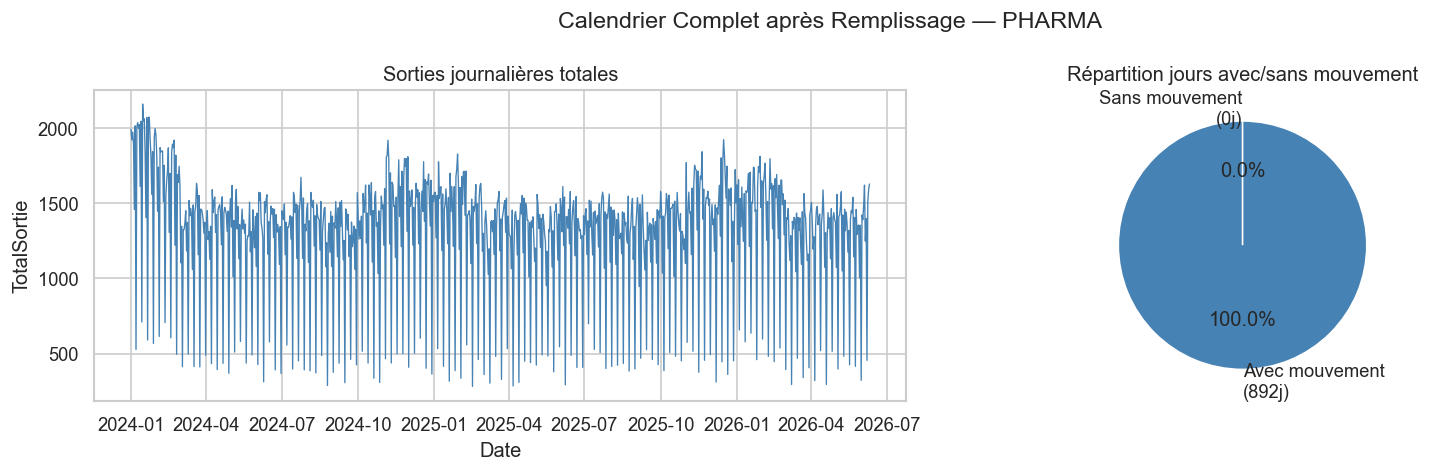

 Graphe sauvegardé : calendrier_complet.png


In [117]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Calendrier Complet après Remplissage — {BASE_NAME}', fontsize=14)

# ── Évolution TotalSortie global ──────────────────────────────
daily = df_total.groupby('DateJour')['TotalSortie'].sum()
axes[0].plot(daily.index, daily.values, color='steelblue', linewidth=0.8)
axes[0].set_title('Sorties journalières totales')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('TotalSortie')

# ── Taux de jours avec mouvement ─────────────────────────────
jours_avec    = (daily > 0).sum()
jours_sans    = (daily == 0).sum()
axes[1].pie(
    [jours_avec, jours_sans],
    labels=[f'Avec mouvement\n({jours_avec}j)', f'Sans mouvement\n({jours_sans}j)'],
    colors=['steelblue', 'lightgray'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Répartition jours avec/sans mouvement')

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}calendrier_complet.png", dpi=120, bbox_inches='tight')
plt.show()
print(" Graphe sauvegardé : calendrier_complet.png")

In [118]:
# Cellule 8 — Filtrer articles ≥ 30 jours de sortie

In [119]:
# ── Compter les jours avec sortie > 0 par article ────────────
jours_sortie = df_total[df_total['TotalSortie'] > 0] \
    .groupby('AR_Ref')['DateJour'].nunique() \
    .reset_index() \
    .rename(columns={'DateJour': 'NbJoursSortie'})

articles_valides = jours_sortie[
    jours_sortie['NbJoursSortie'] >= MIN_JOURS_SORTIE
]['AR_Ref'].tolist()

nb_exclus = df_total['AR_Ref'].nunique() - len(articles_valides)

df_total = df_total[df_total['AR_Ref'].isin(articles_valides)]

print(f"✅ Filtrage articles")
print(f"   Seuil                : ≥ {MIN_JOURS_SORTIE} jours de sortie")
print(f"   Articles retenus     : {len(articles_valides)}")
print(f"   Articles exclus      : {nb_exclus} (trop peu de données)")

✅ Filtrage articles
   Seuil                : ≥ 30 jours de sortie
   Articles retenus     : 154
   Articles exclus      : 0 (trop peu de données)


In [120]:
# Cellule 9 — Features temporelles

In [121]:
# ══════════════════════════════════════════════════════════════
#  CELLULE 9 — Features temporelles (version universelle)
#  Fonctionne sur toute période, toute base, tout secteur
# ══════════════════════════════════════════════════════════════
import holidays as hd

# ── Features de base ─────────────────────────────────────────
df_total['jour_semaine']  = df_total['DateJour'].dt.dayofweek
df_total['mois']          = df_total['DateJour'].dt.month
df_total['trimestre']     = df_total['DateJour'].dt.quarter
df_total['annee']         = df_total['DateJour'].dt.year
df_total['is_weekend']    = (df_total['DateJour'].dt.dayofweek >= 5).astype(int)
df_total['is_fin_mois']   = (df_total['DateJour'].dt.day >= 25).astype(int)
df_total['is_debut_mois'] = (df_total['DateJour'].dt.day <= 5).astype(int)
df_total['mois_label']    = df_total['DateJour'].dt.to_period('M').astype(str)

# ── ✅ NOUVEAU : Jours fériés marocains dynamiques ────────────
annees = df_total['DateJour'].dt.year.unique().tolist()
try:
    ma_holidays = hd.Morocco(years=annees)
    jours_feries = set(pd.to_datetime(list(ma_holidays.keys())).normalize())
    df_total['is_ferie'] = df_total['DateJour'].isin(jours_feries).astype(int)
    print(f"✅ Jours fériés Maroc : {len(jours_feries)} jours sur {annees}")
except Exception:
    df_total['is_ferie'] = 0
    print("⚠️  holidays non disponible — is_ferie = 0")

# ── ✅ NOUVEAU : Ramadan dynamique (approximatif) ─────────────
# Dates Ramadan approximatives par année — s'étend automatiquement
ramadan_dates = {
    2019: ('2019-05-05', '2019-06-04'),
    2020: ('2020-04-23', '2020-05-23'),
    2021: ('2021-04-12', '2021-05-11'),
    2022: ('2022-04-02', '2022-05-01'),
    2023: ('2023-03-22', '2023-04-20'),
    2024: ('2024-03-10', '2024-04-08'),
    2025: ('2025-02-28', '2025-03-29'),
    2026: ('2026-02-17', '2026-03-18'),
}

def is_ramadan(date, ramadan_dict):
    year = date.year
    if year in ramadan_dict:
        start, end = ramadan_dict[year]
        return int(pd.Timestamp(start) <= date <= pd.Timestamp(end))
    return 0

df_total['is_ramadan'] = df_total['DateJour'].apply(
    lambda d: is_ramadan(d, ramadan_dates)
)

ramadan_count = df_total['is_ramadan'].sum()
print(f"✅ Feature Ramadan : {ramadan_count:,} jours de Ramadan détectés")

# ── Lags & Rolling ────────────────────────────────────────────
df_total = df_total.sort_values(['AR_Ref', 'DateJour'])

for lag in [1, 7, 30]:
    df_total[f'sortie_lag_{lag}'] = df_total.groupby('AR_Ref')['TotalSortie'] \
                                             .shift(lag)

for window in [7, 30]:
    df_total[f'rolling_mean_{window}'] = df_total.groupby('AR_Ref')['TotalSortie'] \
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())

# ── ✅ NOUVEAU : Jours avant rupture robuste ──────────────────
# Si StockFinal = 0 → rupture immédiate = 0
# Si rythme_sortie = 0 → pas de rupture prévisible = NaN
# Si stock < 0 → déjà géré (clip à 0 cellule précédente)
rythme = df_total.groupby('AR_Ref')['TotalSortie'] \
                 .transform(lambda x: x.shift(1)
                             .rolling(7, min_periods=1).mean())

rythme_safe = rythme.replace(0, np.nan)  # éviter division par zéro
df_total['jours_avant_rupture'] = (df_total['StockFinal'] / rythme_safe).clip(lower=0)

# NaN là où rythme = 0 (article quasi-immobile) — normal et attendu
jav_nan = df_total['jours_avant_rupture'].isnull().sum()
jav_ok  = df_total['jours_avant_rupture'].notnull().sum()
print(f"✅ Feature jours_avant_rupture")
print(f"   Calculé  : {jav_ok:,} lignes")
print(f"   NaN      : {jav_nan:,} (articles quasi-immobiles — normal)")

print(f"\n✅ Features temporelles créées")
print(f"   Colonnes créées : {[c for c in df_total.columns if c not in ['DateJour','AR_Ref','AR_Design','FA_CodeFamille','FA_Intitule','TotalSortie','TotalEntree','ValeurSortie','ValeurEntree','StockFinal']]}")

✅ Jours fériés Maroc : 51 jours sur [2024, 2025, 2026]
✅ Feature Ramadan : 13,860 jours de Ramadan détectés
✅ Feature jours_avant_rupture
   Calculé  : 132,211 lignes
   NaN      : 5,157 (articles quasi-immobiles — normal)

✅ Features temporelles créées
   Colonnes créées : ['jour_semaine', 'mois', 'trimestre', 'annee', 'is_weekend', 'is_fin_mois', 'is_debut_mois', 'mois_label', 'is_ferie', 'is_ramadan', 'sortie_lag_1', 'sortie_lag_7', 'sortie_lag_30', 'rolling_mean_7', 'rolling_mean_30', 'jours_avant_rupture']


In [122]:
# Cellule 9b — Graphe features temporelles

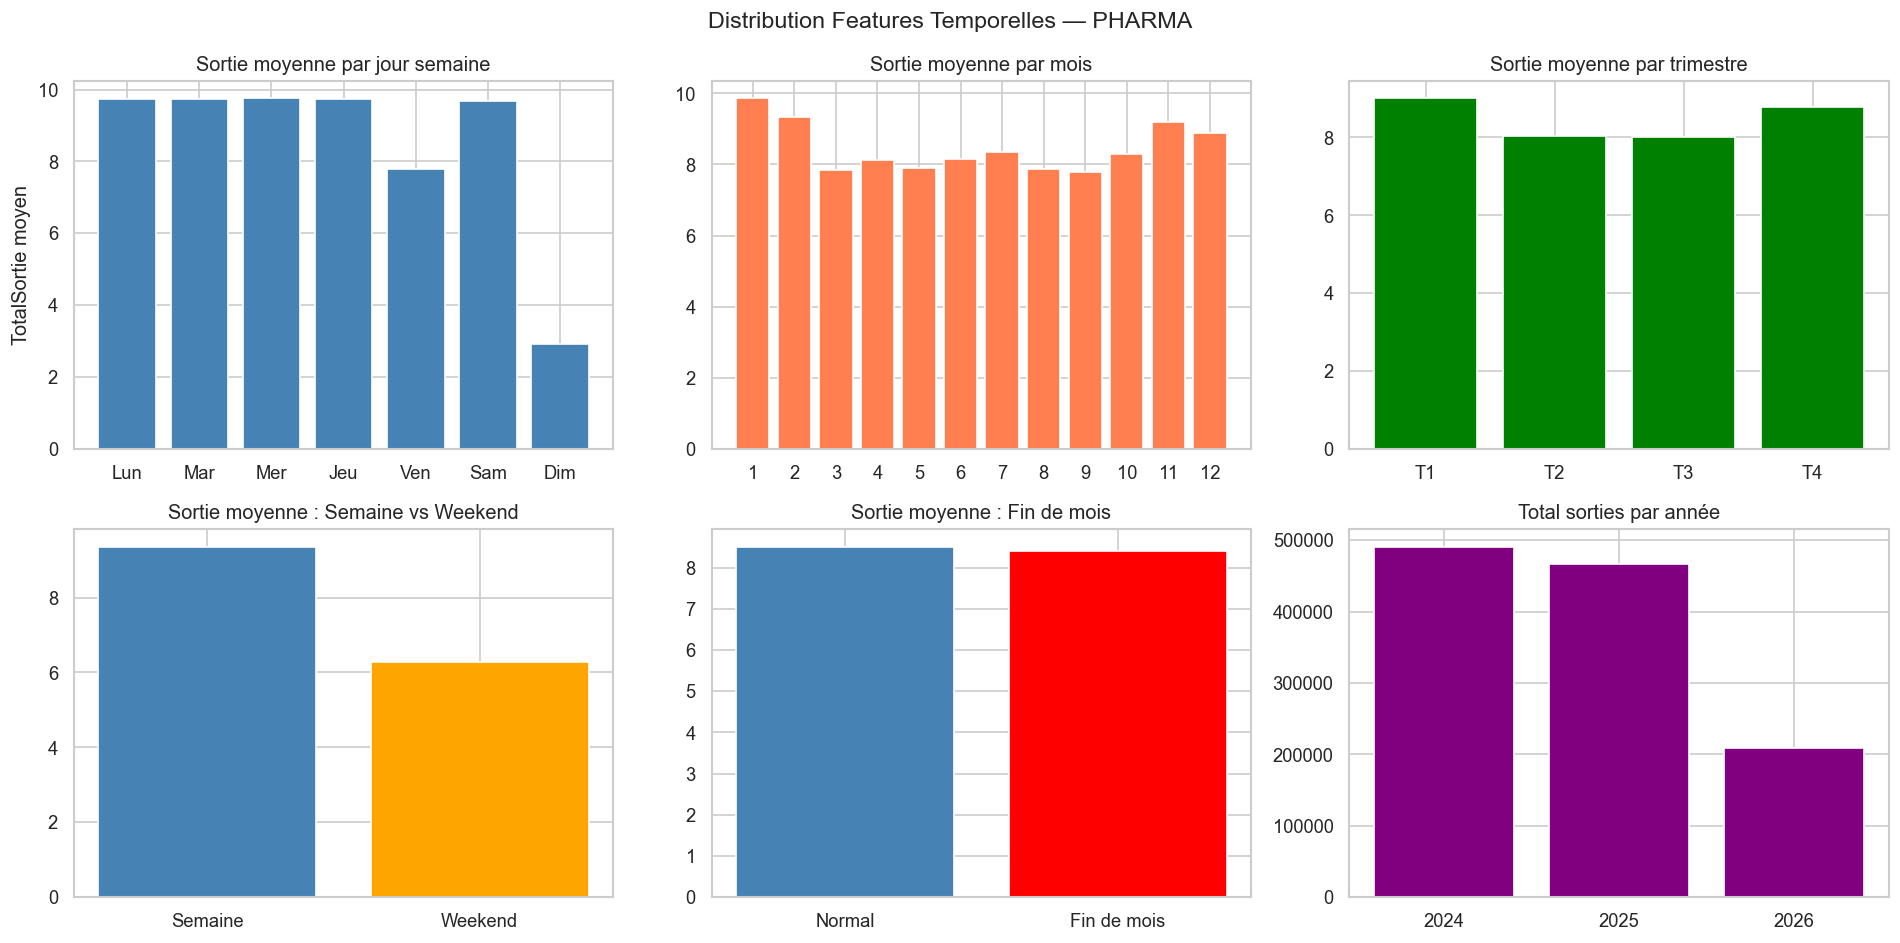

Graphe sauvegardé : features_temporelles.png


In [123]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f'Distribution Features Temporelles — {BASE_NAME}', fontsize=14)

# ── Sorties par jour de semaine ───────────────────────────────
jours_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
by_jour = df_total.groupby('jour_semaine')['TotalSortie'].mean()
axes[0,0].bar(jours_labels, by_jour.values, color='steelblue')
axes[0,0].set_title('Sortie moyenne par jour semaine')
axes[0,0].set_ylabel('TotalSortie moyen')

# ── Sorties par mois ──────────────────────────────────────────
by_mois = df_total.groupby('mois')['TotalSortie'].mean()
axes[0,1].bar(range(1,13), by_mois.values, color='coral')
axes[0,1].set_title('Sortie moyenne par mois')
axes[0,1].set_xticks(range(1,13))

# ── Sorties par trimestre ─────────────────────────────────────
by_trim = df_total.groupby('trimestre')['TotalSortie'].mean()
axes[0,2].bar([f'T{i}' for i in range(1,5)], by_trim.values, color='green')
axes[0,2].set_title('Sortie moyenne par trimestre')

# ── Weekend vs Semaine ────────────────────────────────────────
by_weekend = df_total.groupby('is_weekend')['TotalSortie'].mean()
axes[1,0].bar(['Semaine', 'Weekend'], by_weekend.values, color=['steelblue','orange'])
axes[1,0].set_title('Sortie moyenne : Semaine vs Weekend')

# ── Fin de mois vs normal ─────────────────────────────────────
by_finmois = df_total.groupby('is_fin_mois')['TotalSortie'].mean()
axes[1,1].bar(['Normal', 'Fin de mois'], by_finmois.values, color=['steelblue','red'])
axes[1,1].set_title('Sortie moyenne : Fin de mois')

# ── Évolution annuelle ────────────────────────────────────────
by_annee = df_total.groupby('annee')['TotalSortie'].sum()
axes[1,2].bar(by_annee.index.astype(str), by_annee.values, color='purple')
axes[1,2].set_title('Total sorties par année')

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}features_temporelles.png", dpi=120, bbox_inches='tight')
plt.show()
print("Graphe sauvegardé : features_temporelles.png")

In [124]:
# Cellule 10 — Features lag (Random Forest)

In [125]:
# ── Lags calculés par article ─────────────────────────────────
# shift(n) = valeur d'il y a n jours
# rolling  = moyenne glissante des n derniers jours

df_total = df_total.sort_values(['AR_Ref', 'DateJour'])

grp = df_total.groupby('AR_Ref')['TotalSortie']

df_total['sortie_lag_1']    = grp.shift(1)
df_total['sortie_lag_7']    = grp.shift(7)
df_total['sortie_lag_30']   = grp.shift(30)
df_total['rolling_mean_7']  = grp.transform(
    lambda x: x.shift(1).rolling(7,  min_periods=1).mean()
)
df_total['rolling_mean_30'] = grp.transform(
    lambda x: x.shift(1).rolling(30, min_periods=1).mean()
)

lag_cols = ['sortie_lag_1','sortie_lag_7','sortie_lag_30',
            'rolling_mean_7','rolling_mean_30']

print("Features lag créées")
for col in lag_cols:
    nan_pct = df_total[col].isnull().sum() / len(df_total) * 100
    print(f"   {col:20s} → NaN : {nan_pct:.1f}%")

Features lag créées
   sortie_lag_1         → NaN : 0.1%
   sortie_lag_7         → NaN : 0.8%
   sortie_lag_30        → NaN : 3.4%
   rolling_mean_7       → NaN : 0.1%
   rolling_mean_30      → NaN : 0.1%


In [126]:
# Cellule 10b — Graphe features lag

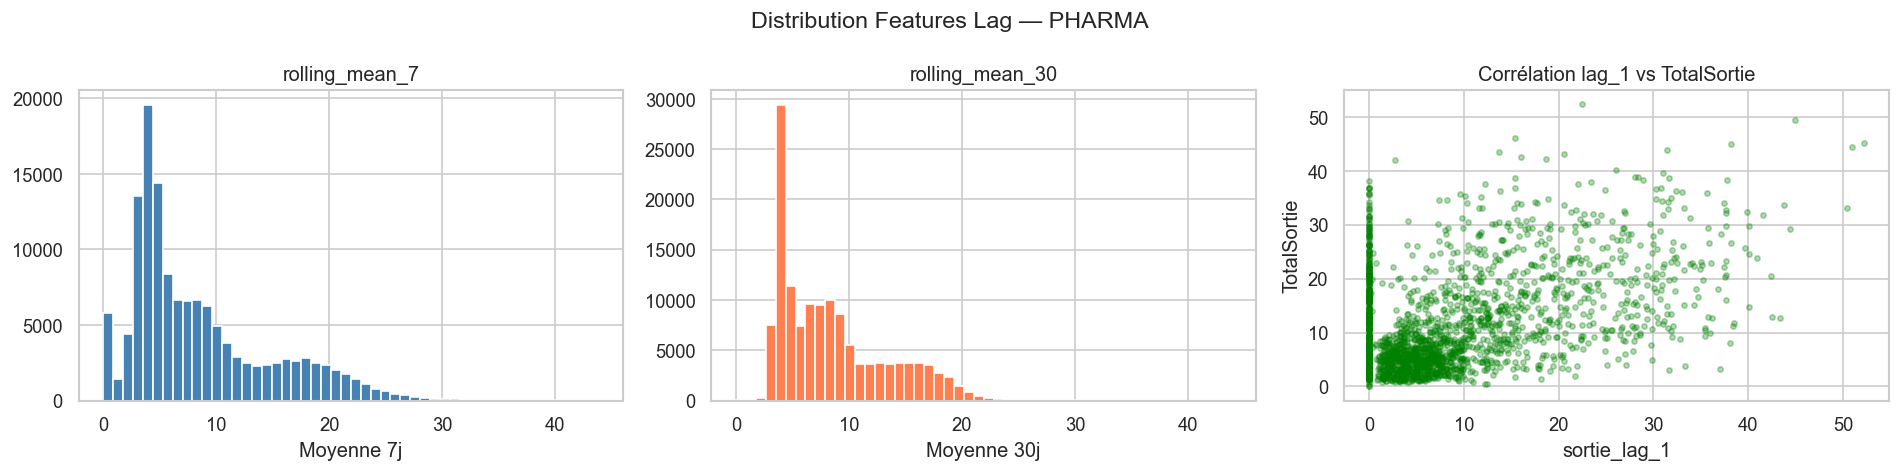

✅ Graphe sauvegardé : features_lag.png


In [127]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Distribution Features Lag — {BASE_NAME}', fontsize=14)

# ── Distribution rolling_mean_7 ───────────────────────────────
axes[0].hist(
    df_total['rolling_mean_7'].dropna(),
    bins=50, color='steelblue', edgecolor='white'
)
axes[0].set_title('rolling_mean_7')
axes[0].set_xlabel('Moyenne 7j')

# ── Distribution rolling_mean_30 ─────────────────────────────
axes[1].hist(
    df_total['rolling_mean_30'].dropna(),
    bins=50, color='coral', edgecolor='white'
)
axes[1].set_title('rolling_mean_30')
axes[1].set_xlabel('Moyenne 30j')

# ── Corrélation lag_1 vs TotalSortie ─────────────────────────
sample = df_total[df_total['TotalSortie'] > 0].sample(
    min(2000, len(df_total)), random_state=42
)
axes[2].scatter(
    sample['sortie_lag_1'],
    sample['TotalSortie'],
    alpha=0.3, s=10, color='green'
)
axes[2].set_title('Corrélation lag_1 vs TotalSortie')
axes[2].set_xlabel('sortie_lag_1')
axes[2].set_ylabel('TotalSortie')

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}features_lag.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Graphe sauvegardé : features_lag.png")

In [128]:
# Cellule 11 — Target Random Forest

In [129]:
# ── jours_avant_rupture ───────────────────────────────────────
# = combien de jours avant rupture si même rythme de sortie
# = StockFinal / moyenne_sortie_7j
# = NaN si moyenne = 0 ou StockFinal négatif

df_total['jours_avant_rupture'] = np.where(
    (df_total['rolling_mean_7'] > 0) & (df_total['StockFinal'] >= 0),
    (df_total['StockFinal'] / df_total['rolling_mean_7']).round(1),
    np.nan
)

df_total['jours_avant_rupture'] = df_total['jours_avant_rupture'].clip(upper=365)

# ── Statistiques sur la target ────────────────────────────────
target_valide = df_total['jours_avant_rupture'].dropna()
print("✅ Target Random Forest créée")
print(f"   Lignes avec target valide : {len(target_valide):,}")
print(f"   Lignes sans target (NaN)  : {df_total['jours_avant_rupture'].isnull().sum():,}")
print(f"   Moyenne jours avant rupture : {target_valide.mean():.1f}j")
print(f"   Min : {target_valide.min():.1f}j  |  Max : {target_valide.max():.1f}j")

✅ Target Random Forest créée
   Lignes avec target valide : 132,211
   Lignes sans target (NaN)  : 5,157
   Moyenne jours avant rupture : 64.8j
   Min : 0.0j  |  Max : 365.0j


In [130]:
# Cellule 11b — Graphe target jours_avant_rupture

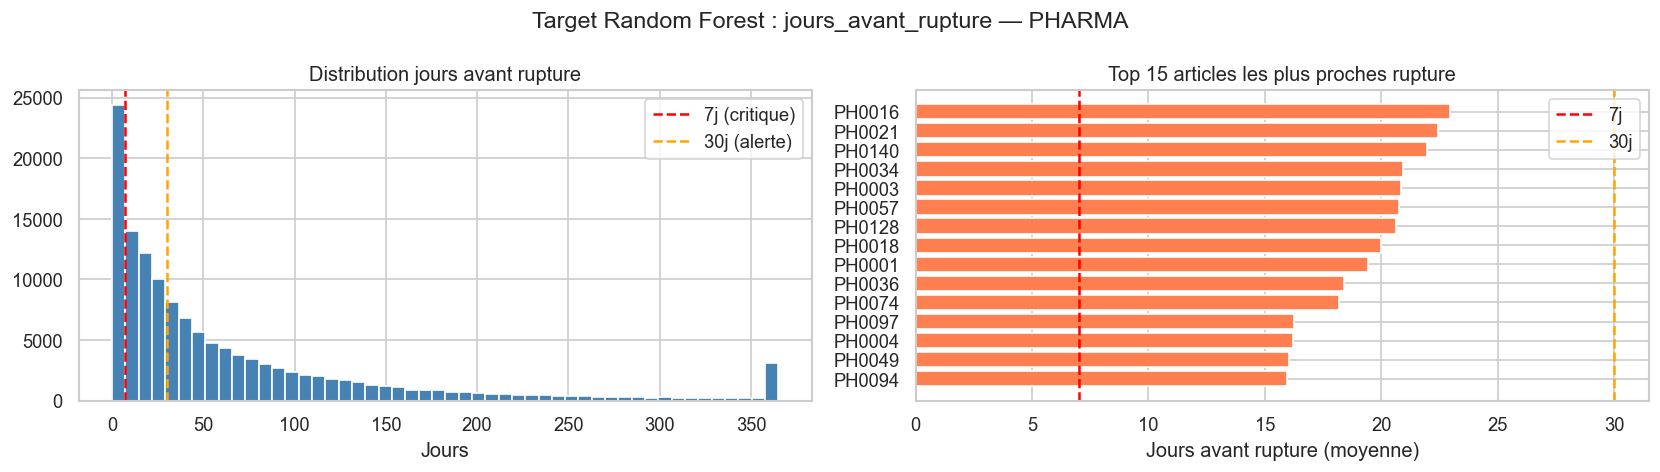

Graphe sauvegardé : target_rupture.png


In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Target Random Forest : jours_avant_rupture — {BASE_NAME}', fontsize=14)

target_valide = df_total['jours_avant_rupture'].dropna()
target_clip   = target_valide.clip(upper=365)  # limiter à 1 an pour la lisibilité

# ── Distribution ──────────────────────────────────────────────
axes[0].hist(target_clip, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(x=7,  color='red',    linestyle='--', label='7j (critique)')
axes[0].axvline(x=30, color='orange', linestyle='--', label='30j (alerte)')
axes[0].set_title('Distribution jours avant rupture')
axes[0].set_xlabel('Jours')
axes[0].legend()

# ── Top articles les plus en danger ──────────────────────────
top_danger = df_total[df_total['jours_avant_rupture'] > 0] \
    .groupby('AR_Ref')['jours_avant_rupture'].mean() \
    .nsmallest(15) \
    .sort_values()

axes[1].barh(top_danger.index, top_danger.values, color='coral')
axes[1].axvline(x=7,  color='red',    linestyle='--', label='7j')
axes[1].axvline(x=30, color='orange', linestyle='--', label='30j')
axes[1].set_title('Top 15 articles les plus proches rupture')
axes[1].set_xlabel('Jours avant rupture (moyenne)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}target_rupture.png", dpi=120, bbox_inches='tight')
plt.show()
print("Graphe sauvegardé : target_rupture.png")

In [132]:
# Cellule 12 — Dataset K-Means mensuel + normalisation

In [133]:
# ── Pivot AR_Ref × mois ───────────────────────────────────────
# Les colonnes mois sont créées automatiquement depuis les données
# → s'adapte à n'importe quelle période

df_total['mois_label'] = df_total['DateJour'].dt.to_period('M').astype(str)

df_kmeans = df_total.pivot_table(
    index   = 'AR_Ref',
    columns = 'mois_label',
    values  = 'TotalSortie',
    aggfunc = 'sum',
    fill_value = 0
)

# ── Normalisation pour K-Means ────────────────────────────────
scaler = StandardScaler()
df_kmeans_scaled = pd.DataFrame(
    scaler.fit_transform(df_kmeans),
    index   = df_kmeans.index,
    columns = df_kmeans.columns
)

print("- Dataset K-Means construit")
print(f"   Articles : {df_kmeans.shape[0]}")
print(f"   Mois     : {df_kmeans.shape[1]}")
print(f"   Période  : {df_kmeans.columns[0]} → {df_kmeans.columns[-1]}")
print(f"\n- Normalisation StandardScaler appliquée")

- Dataset K-Means construit
   Articles : 154
   Mois     : 30
   Période  : 2024-01 → 2026-06

- Normalisation StandardScaler appliquée


In [134]:
# Cellule 12b — Graphe K-Means (heatmap mensuelle)

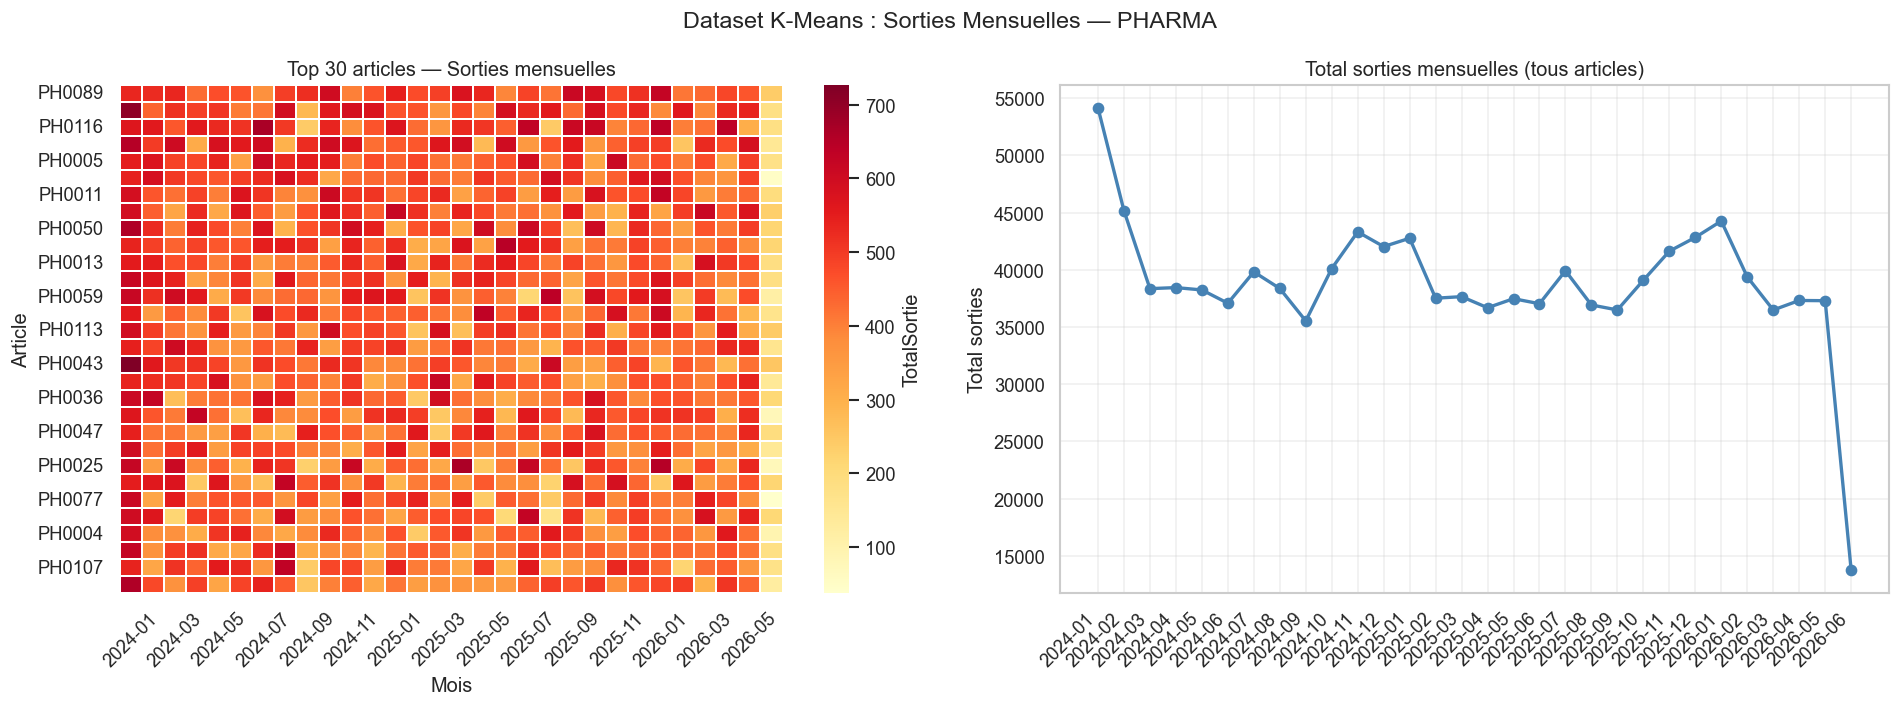

- Graphe sauvegardé : kmeans_mensuel.png


In [135]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Dataset K-Means : Sorties Mensuelles — {BASE_NAME}', fontsize=14)

# ── Heatmap top 30 articles ───────────────────────────────────
top_articles = df_kmeans.sum(axis=1).nlargest(30).index
sns.heatmap(
    df_kmeans.loc[top_articles],
    ax=axes[0],
    cmap='YlOrRd',
    linewidths=0.1,
    cbar_kws={'label': 'TotalSortie'}
)
axes[0].set_title('Top 30 articles — Sorties mensuelles')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Article')
axes[0].tick_params(axis='x', rotation=45)

# ── Évolution totale mensuelle ────────────────────────────────
total_mensuel = df_kmeans.sum(axis=0)
axes[1].plot(
    range(len(total_mensuel)),
    total_mensuel.values,
    marker='o', color='steelblue', linewidth=2
)
axes[1].set_xticks(range(len(total_mensuel)))
axes[1].set_xticklabels(total_mensuel.index, rotation=45, ha='right')
axes[1].set_title('Total sorties mensuelles (tous articles)')
axes[1].set_ylabel('Total sorties')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{EXPLORE_DIR}kmeans_mensuel.png", dpi=120, bbox_inches='tight')
plt.show()
print("- Graphe sauvegardé : kmeans_mensuel.png")

In [136]:
# Cellule 13 — Construire les 4 datasets

In [137]:
# ── df_prophet ────────────────────────────────────────────────
# Format Prophet : ds (date), y (valeur à prédire)
df_prophet = df_total[[
    'DateJour', 'AR_Ref', 'AR_Design',
    'FA_CodeFamille', 'FA_Intitule',
    'TotalSortie', 'StockFinal',
    'jour_semaine', 'mois', 'trimestre',
    'annee', 'is_weekend', 'is_fin_mois', 'is_debut_mois'
]].rename(columns={
    'DateJour'   : 'ds',
    'TotalSortie': 'y'
}).copy()

# ── df_rf (Random Forest) ─────────────────────────────────────
df_rf = df_total.dropna(subset=['sortie_lag_1', 'rolling_mean_7']).copy()

# ── df_iforest (Isolation Forest) ────────────────────────────
# Tous les mouvements avec features numériques
df_iforest = df_total[[
    'DateJour', 'AR_Ref',
    'TotalSortie', 'TotalEntree',
    'ValeurSortie', 'ValeurEntree',
    'StockFinal',
    'jour_semaine', 'mois', 'trimestre'
]].copy()

print("4 datasets construits")
print(f"   df_prophet  : {len(df_prophet):,} lignes | {df_prophet['AR_Ref'].nunique()} articles")
print(f"   df_rf       : {len(df_rf):,} lignes       | {df_rf['AR_Ref'].nunique()} articles")
print(f"   df_iforest  : {len(df_iforest):,} lignes  | {df_iforest['AR_Ref'].nunique()} articles")
print(f"   df_kmeans   : {df_kmeans.shape[0]} articles × {df_kmeans.shape[1]} mois")

4 datasets construits
   df_prophet  : 137,368 lignes | 154 articles
   df_rf       : 137,214 lignes       | 154 articles
   df_iforest  : 137,368 lignes  | 154 articles
   df_kmeans   : 154 articles × 30 mois


In [138]:
df_prophet.head()

,ds,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,y,StockFinal,jour_semaine,mois,trimestre,annee,is_weekend,is_fin_mois,is_debut_mois
0,2024-01-01,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,27.3401,150.9574,0,1,1,2024,0,0,1
154,2024-01-02,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,24.5682,150.9574,1,1,1,2024,0,0,1
308,2024-01-03,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,18.4431,150.9574,2,1,1,2024,0,0,1
462,2024-01-04,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,29.4474,150.9574,3,1,1,2024,0,0,1
616,2024-01-05,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,16.6501,150.9574,4,1,1,2024,0,0,1


In [139]:
df_rf.head()

,DateJour,AR_Ref,AR_Design,FA_CodeFamille,FA_Intitule,TotalSortie,TotalEntree,ValeurSortie,ValeurEntree,StockFinal,...,is_debut_mois,mois_label,is_ferie,is_ramadan,sortie_lag_1,sortie_lag_7,sortie_lag_30,rolling_mean_7,rolling_mean_30,jours_avant_rupture
154,2024-01-02,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,24.5682,0.0,7456.6182,0.0,150.9574,...,1,2024-01,0,0,27.3401,NaN,NaN,27.340100,27.340100,5.5
308,2024-01-03,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,18.4431,0.0,5700.8766,0.0,150.9574,...,1,2024-01,0,0,24.5682,NaN,NaN,25.954150,25.954150,5.8
462,2024-01-04,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,29.4474,0.0,8955.5727,0.0,150.9574,...,1,2024-01,0,0,18.4431,NaN,NaN,23.450467,23.450467,6.4
616,2024-01-05,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,16.6501,0.0,5007.0214,0.0,150.9574,...,1,2024-01,0,0,29.4474,NaN,NaN,24.949700,24.949700,6.1
770,2024-01-06,PH0001,Amoxicilline 500mg,ANTIB,Antibiotiques,16.4480,0.0,5159.4267,0.0,150.9574,...,0,2024-01,0,0,16.6501,NaN,NaN,23.289780,23.289780,6.5


In [140]:
df_iforest.head()

,DateJour,AR_Ref,TotalSortie,TotalEntree,ValeurSortie,ValeurEntree,StockFinal,jour_semaine,mois,trimestre
0,2024-01-01,PH0001,27.3401,1063.0,8836.7988,334540.3442,150.9574,0,1,1
154,2024-01-02,PH0001,24.5682,0.0,7456.6182,0.0000,150.9574,1,1,1
308,2024-01-03,PH0001,18.4431,0.0,5700.8766,0.0000,150.9574,2,1,1
462,2024-01-04,PH0001,29.4474,0.0,8955.5727,0.0000,150.9574,3,1,1
616,2024-01-05,PH0001,16.6501,0.0,5007.0214,0.0000,150.9574,4,1,1


In [141]:
df_kmeans.head()

mois_label,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
AR_Ref,,,,,,,,,,,,,,,,,,,,,
PH0001,565.6284,478.1731,309.1985,312.0000,453.6216,245.9687,505.3991,271.0106,370.0000,382.0281,...,329.6620,526.8302,334.5078,248.0000,485.8364,363.1636,419.3583,336.2782,372.3635,128.2694
PH0002,136.5427,124.6589,117.3730,120.3943,128.2374,125.2392,109.1033,116.9347,105.5985,120.6629,...,122.0117,119.9868,107.7349,129.9646,138.5042,141.4048,120.0737,113.5175,128.8817,37.1351
PH0003,559.0868,567.6328,488.6451,357.6353,369.2006,300.8599,240.2974,285.1503,225.3503,331.9284,...,302.7086,299.7602,188.0000,200.0000,454.0000,197.0000,318.2881,363.1084,288.6035,181.9194
PH0004,596.7118,380.2882,372.1958,310.4301,511.5137,542.0109,390.2180,318.6315,384.7664,529.8756,...,498.0532,376.5241,343.6992,469.3202,436.6555,438.2424,360.5127,560.5361,420.4132,92.5388
PH0005,549.8940,571.7270,488.4326,480.8196,539.3232,335.2165,610.9933,530.6800,551.4046,547.5092,...,521.9923,326.7864,611.0000,426.0000,471.6371,404.5767,472.4457,316.3638,494.9767,176.4101


In [142]:
# Cellule 14 — Vérification qualité

In [143]:
print("=" * 60)
print("  VÉRIFICATION QUALITÉ")
print("=" * 60)

# ── Trous dans le calendrier ──────────────────────────────────
dates_presentes = df_total['DateJour'].unique()
dates_attendues = pd.date_range(
    df_total['DateJour'].min(),
    df_total['DateJour'].max()
)
trous = len(dates_attendues) - len(dates_presentes)
print(f"\n📅 Calendrier")
print(f"   Trous restants : {trous} jours manquants")

# ── NaN critiques ─────────────────────────────────────────────
print(f"\n📊 NaN critiques")
print(f"   StockFinal          : {df_total['StockFinal'].isnull().sum()}")
print(f"   TotalSortie         : {df_total['TotalSortie'].isnull().sum()}")
print(f"   jours_avant_rupture : {df_total['jours_avant_rupture'].isnull().sum()} (normal si sortie=0)")

# ── Distribution TotalSortie ──────────────────────────────────
print(f"\n📈 Distribution TotalSortie")
print(f"   Jours avec sortie > 0  : {(df_total['TotalSortie'] > 0).sum():,}")
print(f"   Jours avec sortie = 0  : {(df_total['TotalSortie'] == 0).sum():,}")
print(f"   Max sortie journalière : {df_total['TotalSortie'].max():.0f}")
print(f"   Moyenne (jours > 0)    : {df_total[df_total['TotalSortie']>0]['TotalSortie'].mean():.1f}")

  VÉRIFICATION QUALITÉ

📅 Calendrier
   Trous restants : 0 jours manquants

📊 NaN critiques
   StockFinal          : 0
   TotalSortie         : 0
   jours_avant_rupture : 5157 (normal si sortie=0)

📈 Distribution TotalSortie
   Jours avec sortie > 0  : 101,368
   Jours avec sortie = 0  : 36,000
   Max sortie journalière : 63
   Moyenne (jours > 0)    : 11.5


In [144]:
# Cellule 15 — Sauvegarde CSV

In [145]:
df_prophet.to_csv(     f"{OUTPUT_DIR}df_prophet.csv",       index=False)
df_rf.to_csv(          f"{OUTPUT_DIR}df_rf.csv",            index=False)
df_iforest.to_csv(     f"{OUTPUT_DIR}df_iforest.csv",       index=False)
df_kmeans.to_csv(      f"{OUTPUT_DIR}df_kmeans.csv")
df_kmeans_scaled.to_csv(f"{OUTPUT_DIR}df_kmeans_scaled.csv")

print("- Fichiers sauvegardés")
print(f"   📁 {OUTPUT_DIR}")
print(f"   df_prophet.csv")
print(f"   df_rf.csv")
print(f"   df_iforest.csv")
print(f"   df_kmeans.csv")
print(f"   df_kmeans_scaled.csv")

- Fichiers sauvegardés
   📁 ../../output/PHARMA/data_clean/
   df_prophet.csv
   df_rf.csv
   df_iforest.csv
   df_kmeans.csv
   df_kmeans_scaled.csv


In [146]:
# Cellule 16 — Résumé final

In [147]:
print("=" * 60)
print(f"  RÉSUMÉ PREPROCESSING — {BASE_NAME}")
print("=" * 60)
print(f"""
📅 Période originale     : {date_debut_originale} → {date_fin_originale}
📅 Période après clean   : {df_total['DateJour'].min().date()} → {df_total['DateJour'].max().date()}

📦 Articles
   Initiaux             : {nb_articles_initial}
   Retenus (≥{MIN_JOURS_SORTIE}j sortie) : {df_total['AR_Ref'].nunique()}
   Exclus               : {nb_articles_initial - df_total['AR_Ref'].nunique()}

📊 Datasets créés
   df_prophet           : {len(df_prophet):,} lignes
   df_rf                : {len(df_rf):,} lignes
   df_iforest           : {len(df_iforest):,} lignes
   df_kmeans            : {df_kmeans.shape[0]} articles × {df_kmeans.shape[1]} mois

📁 Sauvegardés dans     : {OUTPUT_DIR}
""")

conn.close()
print("Connexion SQL fermée")

  RÉSUMÉ PREPROCESSING — PHARMA

📅 Période originale     : 2024-01-01 → 2026-06-10
📅 Période après clean   : 2024-01-01 → 2026-06-10

📦 Articles
   Initiaux             : 154
   Retenus (≥30j sortie) : 154
   Exclus               : 0

📊 Datasets créés
   df_prophet           : 137,368 lignes
   df_rf                : 137,214 lignes
   df_iforest           : 137,368 lignes
   df_kmeans            : 154 articles × 30 mois

📁 Sauvegardés dans     : ../../output/PHARMA/data_clean/

Connexion SQL fermée
